<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/ML/Linear_Regressionderivative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

# Определение последовательности

**Последовательность** — это отображение из множества натуральных чисел в множество вещественных чисел:

$$
a_n : \mathbb{N} \to \mathbb{R}, \quad n \mapsto a_n
$$

То есть, каждому натуральному $n$ поставлено в соответствие число $a_n$. Последовательность обозначается как $(a_n)_{n=1}^{\infty}$.

---

## Определение предела последовательности (формулировка Вейерштрасса)

Число $a \in \mathbb{R}$ называется **пределом последовательности** $(a_n)$, если:

$$
\forall \varepsilon > 0\ \exists n_0 \in \mathbb{N}\ \text{такое, что}\ \forall n > n_0:\ |a_n - a| < \varepsilon.
$$

Обозначается:

$$
\lim_{n \to \infty} a_n = a
$$



In [ ]:
def sequence(n: np.ndarray) -> np.ndarray:
    return 1/n

In [ ]:
#@title plot
def show_convergence(N: int, sequence):
    n_values = np.arange(1, N + 1)
    a_n_values = sequence(n_values)

    plt.figure(figsize=(10, 2))
    plt.hlines(y=0, xmin=min(a_n_values) - 0.1, xmax=max(a_n_values) + 0.1, color='lightgray')

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=n_values.min(), vmax=n_values.max())
    colors = cmap(norm(n_values))

    plt.scatter(a_n_values, np.zeros_like(a_n_values), color=colors, s=50, label=r'$a_n$')

    plt.title('Convergence of $a_n$ on the Number Line')
    plt.xlabel('Real number line')
    plt.yticks([])
    plt.legend()
    plt.grid(True, axis='x')
    plt.show()



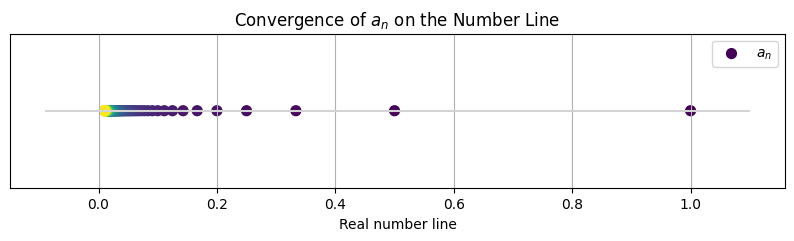

In [ ]:
show_convergence(100, sequence)

# Определение предела функции (в точке $x_0$)

Пусть $f: \mathbb{R} \to \mathbb{R}$ и $x_0 \in \mathbb{R}$. Тогда число $a \in \mathbb{R}$ называется **пределом функции** $f$ в точке $x_0$, если:

$$
\forall \varepsilon > 0\ \exists \delta > 0\ \text{такое, что}\ \forall x \in \mathbb{R},\ 0 < |x - x_0| < \delta:\ |f(x) - a| < \varepsilon.
$$




### Определение словами:

Число $a \in \mathbb{R}$ называется **пределом функции** $f$ в точке $x_0$, если:

> для **любого** положительного числа $\varepsilon > 0$ **существует** положительное число $\delta > 0$, такое что **для всех** $x \in \mathbb{R}$, удовлетворяющих неравенству $0 < |x - x_0| < \delta$, выполняется неравенство $|f(x) - a| < \varepsilon$.

Иными словами, значения функции $f(x)$, соответствующие аргументам $x$, лежащим в проколотой δ-окрестности точки $x_0$, находятся в пределах ε-окрестности числа $a$.





Обозначается:

$$
\lim_{x \to x_0} f(x) = a
$$


## Пример для $y = x^2$

In [ ]:
#@title plot
def f(x):
    return x**2

def compute_epsilon(x0, delta):
    x_test = np.linspace(x0 - delta, x0 + delta, 1000)
    x_test = x_test[x_test != x0]
    y_test = f(x_test)
    a = f(x0)
    return np.max(np.abs(y_test - a))

def plot_limit(x0=1.0, delta=0.5):
    a = f(x0)
    epsilon = compute_epsilon(x0, delta)
    x_vals = np.linspace(x0 - 4, x0 + 4, 1000)
    y_vals = f(x_vals)
    epsilon_mask = (np.abs(y_vals - a) < epsilon)
    delta_mask = (np.abs(x_vals - x0) < delta)
    both_mask = epsilon_mask & delta_mask

    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, y_vals, label=r'$f(x) = x^2$', color='blue')
    plt.plot(x_vals[both_mask], y_vals[both_mask], color='orange', linewidth=3, label='Within ε-δ zone')
    plt.hlines([a - epsilon, a + epsilon], x_vals[0], x_vals[-1], colors='red', linestyles='--', label=r'$\varepsilon$-neighborhood')
    plt.fill_between(x_vals, a - epsilon, a + epsilon, color='red', alpha=0.1)
    plt.vlines([x0 - delta, x0 + delta], min(y_vals), max(y_vals), colors='green', linestyles='--', label=r'$\delta$-neighborhood')
    plt.fill_betweenx(np.linspace(min(y_vals), max(y_vals), 500), x0 - delta, x0 + delta, color='green', alpha=0.1)
    plt.plot(x0, a, 'ro', markerfacecolor='white', markersize=8, label='Limit point (open circle)')
    plt.title(f'Limit of $f(x) = x^2$ at $x_0 = {x0:.2f}$ with δ = {delta:.2f} → ε ≈ {epsilon:.3f}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_limit,
         x0=FloatSlider(value=1.0, min=-2.0, max=7.0, step=0.1, description='x₀'),
         delta=FloatSlider(value=0.5, min=0.01, max=1.0, step=0.01, description='δ'))


interactive(children=(FloatSlider(value=1.0, description='x₀', max=7.0, min=-2.0), FloatSlider(value=0.5, desc…

<function __main__.plot_limit(x0=1.0, delta=0.5)>

# Derivative

Общее определение производной:

$$\frac{dy}{dx} = \lim\limits_{\Delta x \to 0} \frac{f(x+\Delta x) - f(x)}{\Delta x}$$

В этой работе мы научимся вычислять приближенные значения производных в точке:

$$\frac{dy}{dx}(x) \approx \frac{f(x + \varepsilon) - f(x)}{\varepsilon}$$

Где $\varepsilon$ - очень маленькое число.

## Task
Напишем программу рассчета значения производной в точке для функции

$$y = x^3 - 2x^2 + 6$$

In [ ]:
def func(x:float)->float:
  return (x**3 - 2*x**2 + 6)

def derivative(x:float, func)->float:
  'Derivative at point `x` of function `func`'
  dx = 10**(-6)
  return (func(x + dx) - func(x)) / dx

In [ ]:
func(4) # Значение функции f(x) при x=4

38

In [ ]:
derivative(4, func) # Значение производной функции f`(x) при x=4

32.00001000180919

Сделаем проверку:

$ y = x^3 - 2x^2 + 6 $

$ \frac{dy}{dx} = 3x^2 - 4x $

$ \frac{dy}{dx}(4) = 3*4^2 - 4*4 $

In [ ]:
3*4**2 - 4*4

Вывод: Наш код позволил вычислить значение производной с высокой точностью.

## Task

* Напишите программу для нахождения значений функции (Не забудьте про ограничения для аргумента: $x^2+2x+3 > 0$)

$$f(x) = \ln{\sqrt{x^2 + 2x + 3}}$$

* Постройте график производной! Используйте наш метод `derivative(x:float, func)`

* Что можно сказать про родительскую функцию оценивая график ее производной?

In [ ]:
import numpy as np

def f(x):
    return np.log(np.sqrt(x**2 + 2*x + 3))


In [ ]:
x_perv = np.linspace(-10, 10, 100)
x_perv = x_perv[x_perv ** 2 + 2 * x_perv + 3 > 0]

In [ ]:
x_perv.shape

(100,)

In [ ]:
x_perv

array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
         2.12121212,   2.32323232,   2.52525253,   2.72

In [ ]:
y_prev = f(x_perv)

In [ ]:
y_der = derivative(x_perv, f)

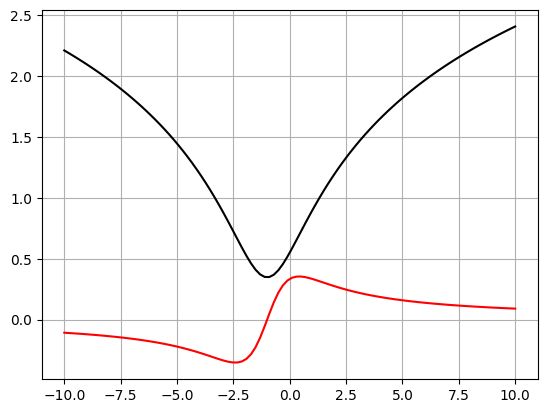

In [ ]:
sns.lineplot(x = x_perv, y = y_prev, color = 'black')
sns.lineplot(x = x_perv, y = y_der, color = 'red')
plt.grid()

# Касательная

Получим множество точек для построения  касательной к графику в точке $x_0$ и сделаем визуализацию.

$$y_{tan} = f'(x_0)(x-x_0) + f(x_0)$$

Пример реализации на Python:

```python
def tangent(x0, func):
    dx = 1e-6
    k = (func(x0 + dx) - func(x0)) / dx
    xxx = np.linspace(x0 - 5, x0 + 5, 100)
    yyy = (xxx - x0) * k + func(x0)
    return xxx, yyy

```



---

Напишем пример для функции $y = \sin{x}$ .

Далее вы можете опробовать какие-либо другие зависимости))

In [ ]:
def func(x:float)->float:
  return np.sin(x)

In [ ]:
#@title plot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider

func_np = np.vectorize(func)

def tangent(x0, func):
    dx = 1e-6
    k = (func(x0 + dx) - func(x0)) / dx
    xxx = np.linspace(x0 - 5, x0 + 5, 100)
    yyy = (xxx - x0) * k + func(x0)
    return xxx, yyy

def plot_with_tangent(x0):
    xx = np.linspace(x0 - 5, x0 + 5, 400)
    yy = func_np(xx)
    xxx, yyy = tangent(x0, func)

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=xx, y=yy, color='g', label='Function')
    sns.lineplot(x=xxx, y=yyy, color='r', label='Tangent')
    plt.plot(x0, func(x0), 'ko', markersize=8, label='Touch point')
    plt.title(f'Tangent to f(x) at x₀ = {x0:.2f}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.xlim(x0 - 5, x0 + 5)
    plt.ylim(min(yy) - 1, max(yy) + 1)
    plt.legend()
    plt.show()

interact(plot_with_tangent, x0=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description='x₀'))


interactive(children=(FloatSlider(value=0.0, description='x₀', max=5.0, min=-5.0), Output()), _dom_classes=('w…

<function __main__.plot_with_tangent(x0)>

# Decorator *

Данный раздел не обязательный и подходит для итстинных ценителей абстрактного трэша! ОСТОРОЖНО!

Я предупреждал...
###  Что такое **декоратор функции** в Python?

**Декоратор** — это специальная конструкция, которая позволяет **модифицировать поведение функции** без изменения её исходного кода.

Декоратор — это **функция, принимающая другую функцию как аргумент**, и возвращающая **новую функцию** с изменённым поведением. Декорирование - это "оборачивание" какой-то функции некоторой "оберткой" так, что ваша функция кроме того что она делает сама по себе, начинает обладать каким-то дополнительным функционалом!



## Пример

In [ ]:
def cat()->None:
  print('Мяу....')

cat()

In [ ]:
def barsik(func):
  def wrapper():
    func()

    print('\nКот делает КУСЬ и убегает.......')

  return wrapper

In [ ]:
@barsik
def cat():
  print('Мяу....')

cat()

## Как это работает с производными

```python
@autodiff
def func(x):
    ...
```

Это **эквивалентно** следующему:

```python
def func(x):
    ...

func = autodiff(func)
```

То есть, сначала создаётся функция `func`, потом она "оборачивается" в декоратор `autodiff`, и уже обёрнутая версия под тем же именем становится доступной.

---

### Что делает `@autodiff` в этом примере?

* При вызове `func(x)` теперь фактически вызывается **производная от этой функции**, численно приближённая по формуле:

  $$
  f'(x) \approx \frac{f(x + dx) - f(x)}{dx}
  $$
* Это реализовано с помощью вложенной функции `wrapper`.


In [ ]:
def autodiff(func):

  def wrapper(x):
    print('___AUTO DIFF ___')
    dx = 10**(-6)
    return ( func(x + dx) - func(x) ) / dx
  return wrapper


In [ ]:
@autodiff
def func(x:float)->float:
  return np.sin(x) - np.cos(x)

In [ ]:
func(3)

---

###  Позже в курсе:

Мы **подробно разберём декораторы** в разделе **объектно-ориентированного программирования**, в контексте:

* функций высшего порядка,
* замыканий (closures),
* и написания собственных классов-декораторов.

# Нахождение минимума функции

Когда мы находим локальные максимумы и минимумы функций руками, мы применяем аналитический подход:

$$\frac{\mathrm{d}f}{\mathrm{d}x} = 0$$
Решая данное уравнение мы находим критические точки, среди которых могут быть точки экстремумов.

Однако в программной среде приняты другие алгоритмы, которые итеративным методом позволяют нам найти экстремумы.

Мы предложим подход, который положен в основу "Градиентного спука" с адаптацией для функции одного аргумента $f: \mathbb{R} \to \mathbb{R}$, который нам поможет найти локальный минимум функции:

$$x^n = x^{n-1} - \eta \frac{\mathrm{d}f}{\mathrm{d}x}(x^{n-1})$$


**где:**

* $x^{n}$ — значение аргумента на **n-м шаге** алгоритма;
* $x^{n-1}$ — значение аргумента на **предыдущем (n−1) шаге**;
* $\eta$ (эта, «learning rate») — **скорость обучения**, то есть шаг, с которым мы двигаемся в сторону минимума;
* $\frac{\mathrm{d}f}{\mathrm{d}x}(x^{n-1})$ — **производная функции** $f$ по переменной $x$, вычисленный в точке $x^{n-1}$.. (позже для многомерных случаев мы это будем называть градиентом функции);

Важной особенностью является необходимость инициализировать алгоритм - то есть выбрать произвольную точку с которой у нас начнется поиск локального минимума!




---
Найдем локальный минимум функции:

$$f(x) = \ln{\sqrt{x^2 + 2x + 3}}$$



In [ ]:
def func(x:float)->float:
  return np.log((x**2 + 2*x + 3)**.5)

def grad(fun, x:float)->float:
  dx = 10**(-6)
  return (fun(x + dx) - fun(x)) / dx

In [ ]:
current_x = 7
N_ITER = 30
LearningRate = 1.5
history = []

for _ in range(N_ITER):
  history.append(current_x)
  current_x = current_x - LearningRate * grad(func, current_x)

history.append(current_x)

In [ ]:
history

[7,
 np.float64(6.818181829480679),
 np.float64(6.632400222715489),
 np.float64(6.442393114001959),
 np.float64(6.247868952556573),
 np.float64(6.0485019456532),
 np.float64(5.843926288238926),
 np.float64(5.6337291095761515),
 np.float64(5.417441783860049),
 np.float64(5.194529124195817),
 np.float64(4.964375824111016),
 np.float64(4.726269268971677),
 np.float64(4.4793775242565275),
 np.float64(4.222720832024123),
 np.float64(3.9551343080853556),
 np.float64(3.6752186234542066),
 np.float64(3.3812742626023677),
 np.float64(3.071213594461824),
 np.float64(2.742444168111973),
 np.float64(2.391719136761388),
 np.float64(2.0149663904275243),
 np.float64(1.607171981186866),
 np.float64(1.1626336310562806),
 np.float64(0.6767930121539472),
 np.float64(0.15406227828884056),
 np.float64(-0.36549547686315975),
 np.float64(-0.7616325249441065),
 np.float64(-0.9354698493960818),
 np.float64(-0.9837672771199131),
 np.float64(-0.9959405903107239),
 np.float64(-0.9989854974704677)]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2954131352.py:6: SyntaxWarning: invalid escape sequence '\l'
  sns.lineplot(x=xx, y=yy, color='black', label='$f(x) = \ln{\sqrt{x^2 + 2x + 3}}$')


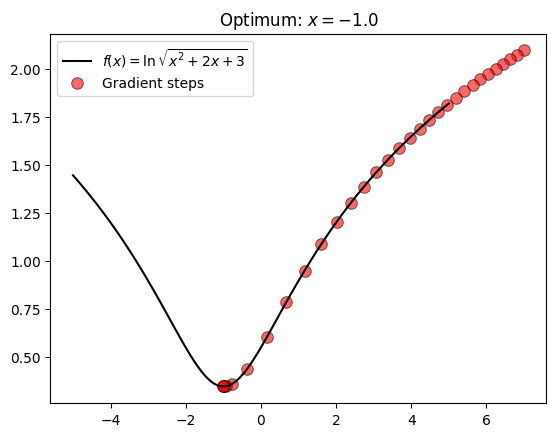

In [ ]:
xx=np.linspace(-5, 5, 100)
yy = func(xx)
history_x = np.array(history)
history_y = func(history_x)

sns.lineplot(x=xx, y=yy, color='black', label='$f(x) = \ln{\sqrt{x^2 + 2x + 3}}$')
sns.scatterplot(x=history_x, y=history_y, color='r', s=70, alpha=.6, edgecolor='black', label='Gradient steps')
plt.title(f'Optimum: $x = {history_x[-1].round(2).item()}$')
plt.legend()

Text(0.5, 1.0, 'Gradient steps')

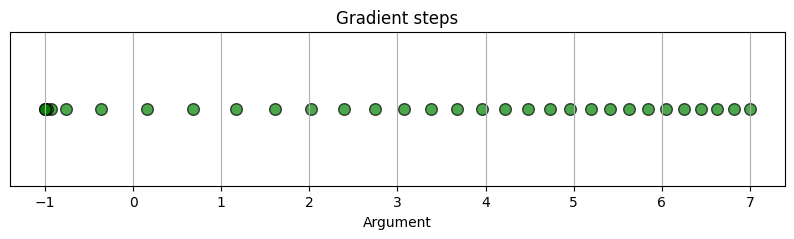

In [ ]:
plt.subplots(figsize=(10, 2))
plt.scatter(history_x, np.zeros_like(history_x), color='g', s=70, alpha=.7, edgecolor='black')
plt.grid()
plt.yticks([])
plt.xlabel('Argument')
plt.title('Gradient steps')

## Task

Найдите локальный минимум функции методом, описанным выше:

$$y = x^4 -3x^3 +3x +1$$

Отследите с помощью визуализации, насколько корректно отработал алгоритм. С какими проблемами вы столкнулись?

(-10.0, 30.0)

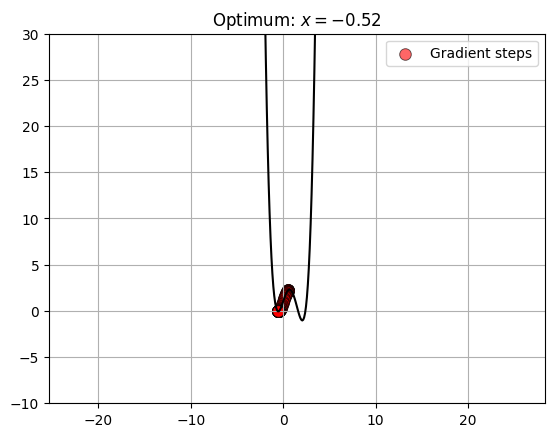

In [ ]:
def func(x:float)->float:
  return (x**4 + - 3*(x**3) + 3*x + 1)
def grad(fun, x:float)->float:
  dx = 10**(-6)
  return (fun(x + dx) - fun(x)) / dx

current_x = 6
N_ITER = 100
LearningRate = 0.01
history = []

for _ in range(N_ITER):
  history.append(current_x)
  current_x = current_x - LearningRate * grad(func, current_x)

history.append(current_x)

xx=np.linspace(-5, 5, 100)
yy = func(xx)
history_x = np.array(history)
history_y = func(history_x)

sns.lineplot(x=xx, y=yy, color='black')
sns.scatterplot(x=history_x, y=history_y, color='r', s=70, alpha=.6, edgecolor='black', label='Gradient steps')
plt.title(f'Optimum: $x = {history_x[-1].round(2).item()}$')
plt.legend()
plt.grid()

plt.axis('equal')
plt.xlim(-1, 4)
plt.ylim(-10, 30)

(-10.0, 30.0)

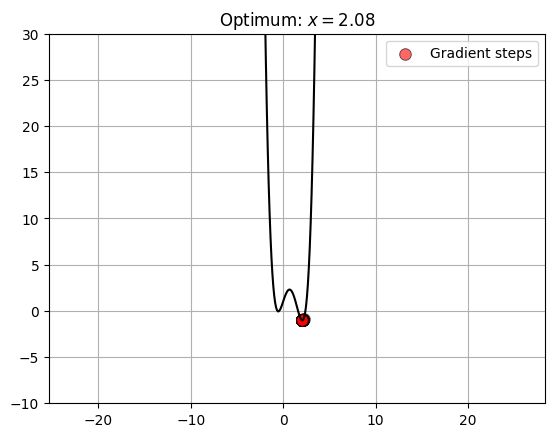

In [ ]:
current_x = 5
N_ITER = 100
LearningRate = 0.01
history = []

for _ in range(N_ITER):
  history.append(current_x)
  current_x = current_x - LearningRate * grad(func, current_x)

history.append(current_x)

xx=np.linspace(-5, 5, 100)
yy = func(xx)
history_x = np.array(history)
history_y = func(history_x)

sns.lineplot(x=xx, y=yy, color='black')
sns.scatterplot(x=history_x, y=history_y, color='r', s=70, alpha=.6, edgecolor='black', label='Gradient steps')
plt.title(f'Optimum: $x = {history_x[-1].round(2).item()}$')
plt.legend()
plt.grid()

plt.axis('equal')
plt.xlim(-1, 4)
plt.ylim(-10, 30)

In [ ]:
def func(x:float)->float:
  return (x**4 + - 3*(x**3) + 3*x + 1)
def grad(fun, x:float)->float:
  dx = 10**(-6)
  return (fun(x + dx) - fun(x)) / dx

In [ ]:
starting_points = [-2,2]
results = []

for start in starting_points:
    x = start
    for _ in range(N_ITER):
        x = x - LearningRate * grad(func, x)
    results.append(x)

print(results)

[-0.5203157455082579, 2.075971892918858]


In [ ]:
starting_points = -2
results = [starting_points]


for _ in range(N_ITER):
    starting_points = starting_points - LearningRate * grad(func, starting_points)
    results.append(starting_points)

print(results)

[-2, -1.3500004200797093, -1.1175604570159408, -0.9793252090386488, -0.8854383816327953, -0.817111019273618, -0.7651983610348339, -0.7245790782619537, -0.6921112485416252, -0.6657383720389802, -0.6440473646331917, -0.626029759982714, -0.6109436718295651, -0.5982296118403045, -0.5874568623123171, -0.5782880497342529, -0.5704550099085974, -0.5637419040329643, -0.5579731313911633, -0.5530044982862119, -0.5487166484887656, -0.5450100965500564, -0.5418014180627022, -0.5390202888047018, -0.5366071561865287, -0.5345113881651802, -0.5326897872750518, -0.531105387119533, -0.5297264697858832, -0.528525757744978, -0.5274797448375761, -0.5265681391288783, -0.5257733964150173, -0.5250803277370135, -0.5244757677371741, -0.5239482933330191, -0.5234879842510569, -0.5230862185658918, -0.5227354976358161, -0.5224292958496672, -0.5221619314013086, -0.5219284549120555, -0.5217245532898023, -0.5215464666266083, -0.5213909162384827, -0.5212550423174793, -0.5211363498283088, -0.5210326615481247, -0.520942077

Text(0.5, 1.0, 'Gradient steps')

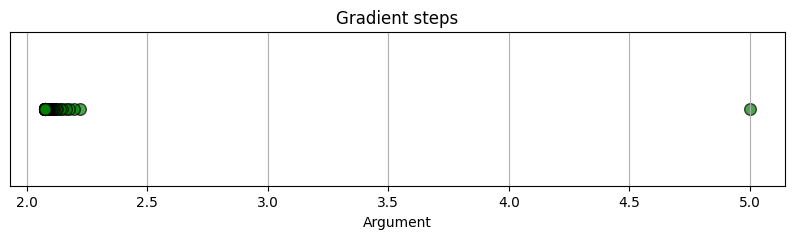

In [ ]:
plt.subplots(figsize=(10, 2))
plt.scatter(history_x, np.zeros_like(history_x), color='g', s=70, alpha=.7, edgecolor='black')
plt.grid()
plt.yticks([])
plt.xlabel('Argument')
plt.title('Gradient steps')

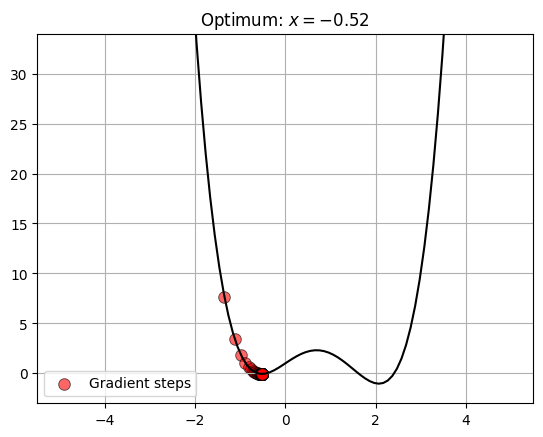

In [ ]:
xx=np.linspace(-5, 5, 100)
yy = func(xx)
history_x = np.array(results)
history_y = func(history_x)

sns.lineplot(x=xx, y=yy, color='black')
sns.scatterplot(x=history_x, y=history_y, color='r', s=70, alpha=.6, edgecolor='black', label='Gradient steps')
plt.title(f'Optimum: $x = {history_x[-1].round(2).item()}$')
plt.ylim(-3, 34)
plt.legend()
plt.grid()

# Производная функции нескольких переменных

Рассмотрим пример:

$$f(x, y) = A * e^{-(\frac{x^2}{2\sigma^2_x} + \frac{y^2}{2\sigma_y^2})}$$

In [ ]:
#@title plot
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider, Dropdown

A = 0.3
sigma_x = 0.8
sigma_y = 1.0

x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)
Z = A * np.exp(-((X**2)/(2 * sigma_x**2) + (Y**2)/(2 * sigma_y**2)))

def plot_gaussian_section(fixed_axis='x', value=0.0):
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_wireframe(X, Y, Z, color='black', alpha=0.4, rstride=10, cstride=10)

    if fixed_axis == 'x':
        x_fixed = np.full_like(y, value)
        y_vals = y
        z_vals = A * np.exp(-((x_fixed**2)/(2 * sigma_x**2) + (y_vals**2)/(2 * sigma_y**2)))
        ax.plot(x_fixed, y_vals, z_vals, color='red', linewidth=2, label=f'x = {value:.2f}')
    elif fixed_axis == 'y':
        y_fixed = np.full_like(x, value)
        x_vals = x
        z_vals = A * np.exp(-((x_vals**2)/(2 * sigma_x**2) + (y_fixed**2)/(2 * sigma_y**2)))
        ax.plot(x_vals, y_fixed, z_vals, color='red', linewidth=2, label=f'y = {value:.2f}')
    elif fixed_axis == 'z':
        ax.contour(X, Y, Z, levels=[value], colors='red', linestyles='solid', linewidths=2, offset=value)
        ax.set_zlim(0, A + 0.1)

    ax.set_title("2D Gaussian Surface with Section")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")
    ax.legend()
    plt.tight_layout()
    plt.show()

interact(
    plot_gaussian_section,
    fixed_axis=Dropdown(options=['x', 'y', 'z'], value='x', description='Fix axis'),
    value=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='Value')
)


interactive(children=(Dropdown(description='Fix axis', options=('x', 'y', 'z'), value='x'), FloatSlider(value=…

<function __main__.plot_gaussian_section(fixed_axis='x', value=0.0)>

Построим градиенты данной фукции:


$$
\nabla_{f(x, y)} =
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix}
=
\begin{bmatrix}
\displaystyle -\frac{A x}{\sigma_x^2} \cdot e^{ -\left( \frac{x^2}{2\sigma_x^2} + \frac{y^2}{2\sigma_y^2} \right) } \\
\\
\displaystyle -\frac{A y}{\sigma_y^2} \cdot e^{ -\left( \frac{x^2}{2\sigma_x^2} + \frac{y^2}{2\sigma_y^2} \right) }
\end{bmatrix}
$$



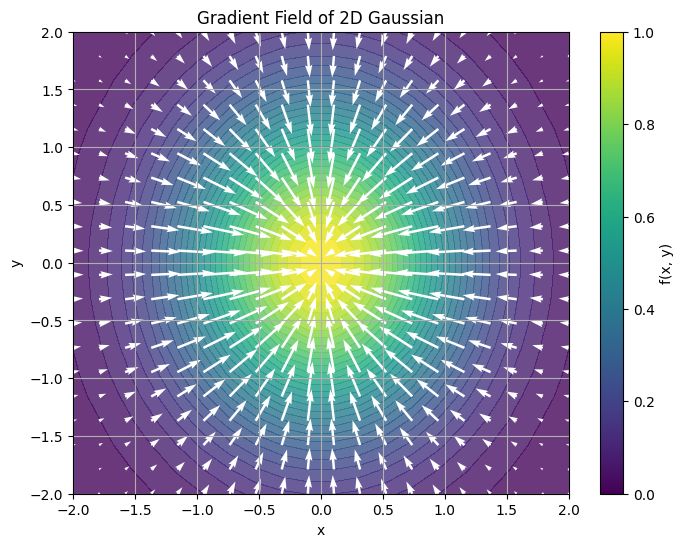

In [ ]:
#@title plot
A = 0.3
sigma_x = 0.8
sigma_y = 1.0

x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)

Z = A * np.exp(-((X**2)/(2 * sigma_x**2) + (Y**2)/(2 * sigma_y**2)))

# ВАЖНО: сначала dy, потом dx
dZ_dy, dZ_dx = np.gradient(Z, y, x)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
plt.quiver(X, Y, dZ_dx, dZ_dy, color='white', scale=2.5, width=0.005)
plt.title("Gradient Field of 2D Gaussian")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.colorbar(label="f(x, y)")
plt.show()




---

Рассмотрим похожий пример но с локальным минимумом:

$$f(x, y) = -A * e^{-(\frac{x^2}{2\sigma^2_x} + \frac{y^2}{2\sigma_y^2})}$$

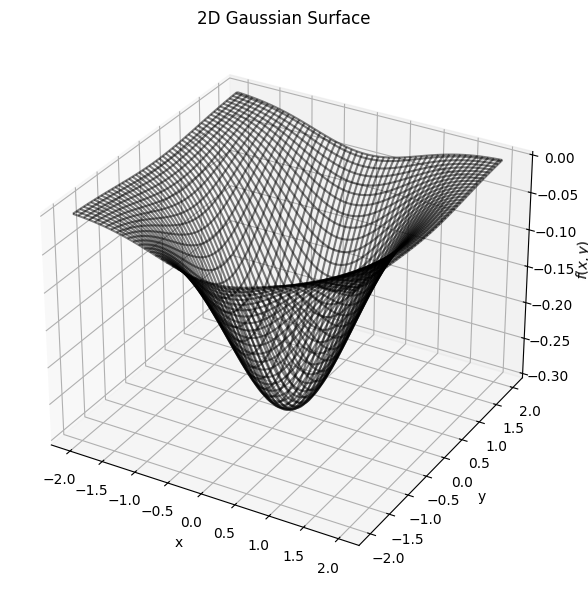

In [ ]:
#@title plot
A = -.3
sigma_x = 0.8
sigma_y = 1
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = A * np.exp(-((X**2)/(2 * sigma_x**2) + (Y**2)/(2 * sigma_y**2)))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(X, Y, Z, color='black', alpha=0.5)

ax.set_title("2D Gaussian Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("$f(x, y)$")

plt.tight_layout()
plt.show()

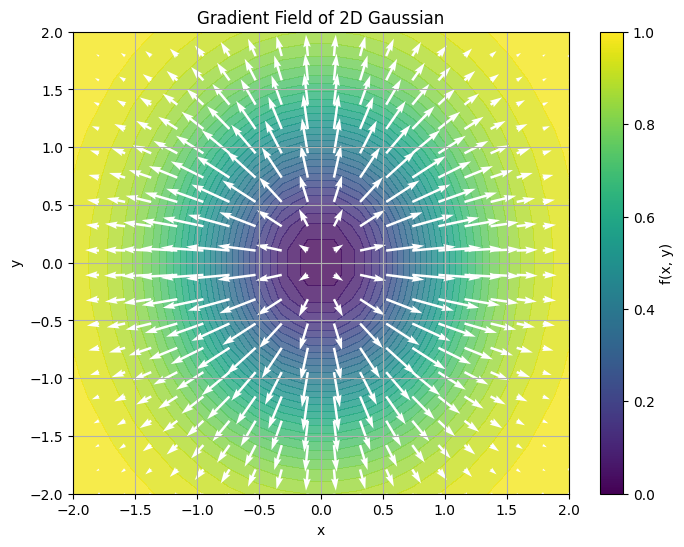

In [ ]:
#@title plot
A = -0.3
sigma_x = 0.8
sigma_y = 1.0

x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)

Z = A * np.exp(-((X**2)/(2 * sigma_x**2) + (Y**2)/(2 * sigma_y**2)))

# ВАЖНО: сначала dy, потом dx
dZ_dy, dZ_dx = np.gradient(Z, y, x)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
plt.quiver(X, Y, dZ_dx, dZ_dy, color='white', scale=2.5, width=0.005)
plt.title("Gradient Field of 2D Gaussian")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.colorbar(label="f(x, y)")
plt.show()

# Приближенное вычисление частных производных

$$\frac{∂f(x, y)}{∂x}(x, y) \approx \frac{f(x + \varepsilon, y) - f(x, y)}{\varepsilon}$$

$$\frac{∂f(x, y)}{∂y}(x, y) \approx \frac{f(x, y + \varepsilon) - f(x, y)}{\varepsilon}$$

Давайте снова поработаем с нашем Гаусcианом:

$$f(x, y) = A * e^{-(\frac{x^2}{2\sigma^2_x} + \frac{y^2}{2\sigma_y^2})}$$

Где:

$A = 0.3$

$\sigma_x = 0.8$

$\sigma_y = 1$

In [ ]:
def gaussian(x:float, y:float)->float:
  A = 0.3
  sigma_x = 0.8
  sigma_y = 1.0
  return A * np.exp(-((x**2)/(2 * sigma_x**2) + (y**2)/(2 * sigma_y**2)))

Методы приближенных вычислений частных производных и градиента:

In [ ]:
def df_dx(x:float, y:float, func)->float:
  dx = 10**(-6)
  return round((func(x+dx, y) - func(x, y)) / dx, 1)

def df_dy(x:float, y:float, func)->float:
  dy = 10**(-6)
  return round((func(x, y+dy) - func(x, y)) / dy, 1)

def gradient(x:float, y:float, func)->np.ndarray:
  return np.array([df_dx(x, y, func),
                   df_dy(x, y, func)])

In [ ]:
df_dx(1, -1, gaussian)

np.float64(-0.1)

In [ ]:
df_dy(1, -1, gaussian)

np.float64(0.1)

In [ ]:
gradient(1, -1, gaussian)

array([-0.1,  0.1])

# Реализация градиентного спуска

$$f(x, y) = -A * e^{-(\frac{x^2}{2\sigma^2_x} + \frac{y^2}{2\sigma_y^2})}$$

$$\{x_1, x_2, ..., x_n\}^k = \{x_1, x_2, ..., x_n\}^{k-1} - \eta\nabla_{f(x_1, x_2, ..., x_n)} $$


In [ ]:
def gaussian(x:float, y:float)->float:
  A = -0.3
  sigma_x = 0.8
  sigma_y = 1.0
  return A * np.exp(-((x**2)/(2 * sigma_x**2) + (y**2)/(2 * sigma_y**2)))

def df_dx(x:float, y:float, func)->float:
  dx = 10**(-6)
  return (func(x+dx, y) - func(x, y)) / dx

def df_dy(x:float, y:float, func)->float:
  dy = 10**(-6)
  return (func(x, y+dy) - func(x, y)) / dy

def gradient(x:float, y:float, func)->np.ndarray:
  return np.array([df_dx(x, y, func),
                   df_dy(x, y, func)])

In [ ]:
LEARNING_RATE = 1
N_ITER = 40
current_point = np.array([-2, .2])

history = [current_point]
for _ in range(N_ITER):
  current_point = current_point - LEARNING_RATE*gradient(x=current_point[0], y=current_point[1], func=gaussian)
  history.append(current_point)

print(*history, sep='\n')
history = np.array(history)

[-2.   0.2]
[-1.95962471  0.19741598]
[-1.91477861  0.19452454]
[-1.86455949  0.19125937]
[-1.80780551  0.18753354]
[-1.74300268  0.18323123]
[-1.66815837  0.17819575]
[-1.5806365   0.17221222]
[-1.47696934  0.16498362]
[-1.35273072  0.1561017 ]
[-1.20276337  0.14502593]
[-1.02257761  0.13112105]
[-0.81262659  0.11389144]
[-0.58670396  0.09362667]
[-0.37745427  0.07225552]
[-0.21957254  0.0529126 ]
[-0.1205914   0.03764684]
[-0.06474258  0.02648814]
[-0.03450456  0.01857031]
[-0.0183486  0.0130052]
[-0.00975092  0.00910485]
[-0.00518094  0.00637356]
[-0.00275271  0.00446142]
[-0.00146263  0.00312287]
[-0.00077726  0.00218586]
[-0.00041316  0.00152996]
[-0.00021972  0.00107082]
[-0.00011696  0.00074942]
[-6.23707715e-05  5.24446685e-04]
[-3.33688040e-05  3.66962715e-04]
[-1.79615174e-05  2.56723952e-04]
[-9.77645369e-06  1.79556791e-04]
[-5.42809868e-06  1.25539778e-04]
[-3.11805763e-06  8.77278574e-05]
[-1.89087261e-06  6.12594744e-05]
[-1.23894965e-06  4.27316285e-05]
[-8.92560066e-07

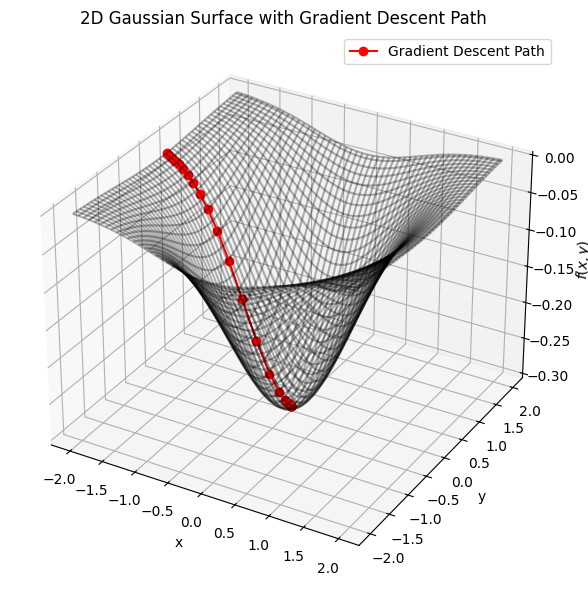

In [ ]:
#@title history plot
A = -0.3
sigma_x = 0.8
sigma_y = 1.0

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = A * np.exp(-((X**2) / (2 * sigma_x**2) + (Y**2) / (2 * sigma_y**2)))

Z_history = A * np.exp(-((history[:, 0]**2) / (2 * sigma_x**2) +
                         (history[:, 1]**2) / (2 * sigma_y**2)))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, Y, Z, color='black', alpha=0.3)

ax.plot(history[:, 0], history[:, 1], Z_history, color='red', marker='o', label='Gradient Descent Path')

ax.set_title("2D Gaussian Surface with Gradient Descent Path")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("$f(x, y)$")
ax.legend()

plt.tight_layout()
plt.show()


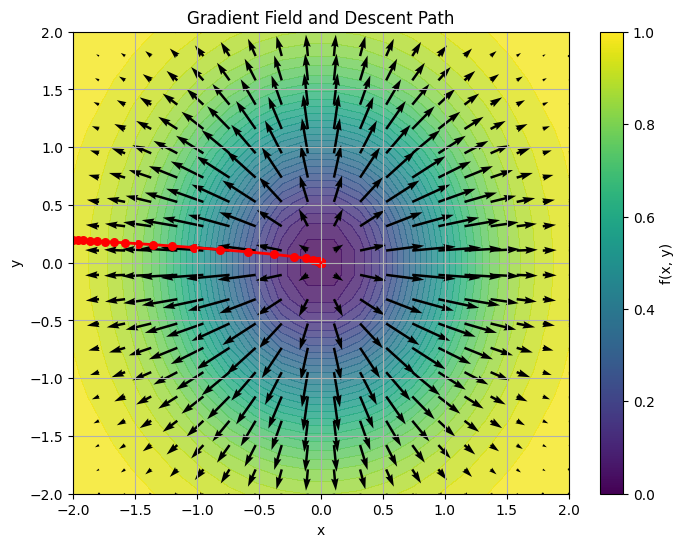

In [ ]:
#@title plot
A = -0.3
sigma_x = 0.8
sigma_y = 1.0


x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)
Z = A * np.exp(-((X**2)/(2 * sigma_x**2) + (Y**2)/(2 * sigma_y**2)))


dZ_dy, dZ_dx = np.gradient(Z, y, x)

Z_history = A * np.exp(-((history[:, 0]**2)/(2 * sigma_x**2) + (history[:, 1]**2)/(2 * sigma_y**2)))

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
plt.quiver(X, Y, dZ_dx, dZ_dy, color='black', scale=2.5, width=0.005)

plt.plot(history[:, 0], history[:, 1], color='red', linewidth=2)
plt.scatter(history[:, 0], history[:, 1], color='red', s=30)

plt.title("Gradient Field and Descent Path")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.colorbar(label="f(x, y)")
plt.show()


# Task

Методом градиентного спуска найдите минимум данной функции.

In [ ]:
def gauss_mixture(x, y)->float:
  A_1 = -0.3
  sigma_x_1 = 1.0
  sigma_y_1 = 1.2
  A_2 = -0.4
  sigma_x_2 = 1
  sigma_y_2 = 1.2
  z = A_1 * np.exp(-(((x-.5)**2)/(2 * sigma_x_1**2) + ((y-1)**2)/(2 * sigma_y_1**2))) + \
  A_2 * np.exp(-(((x + 1)**2)/(2 * sigma_x_2**2) + ((y + 2)**2)/(2 * sigma_y_2**2)))
  return z

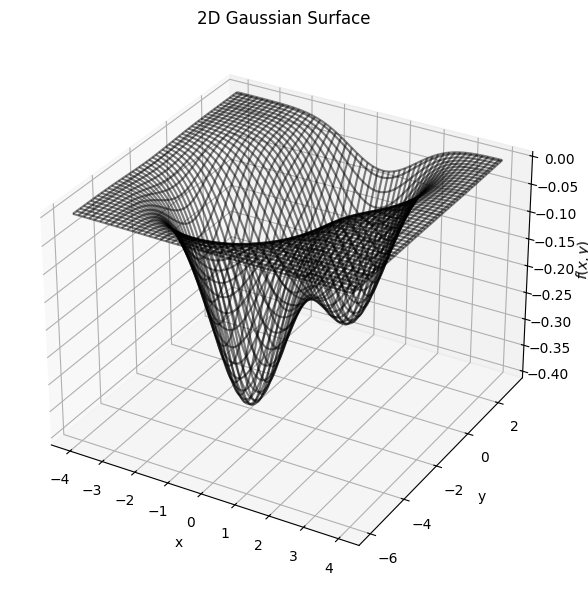

In [ ]:
#@title plot
X, Y = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-6, 3, 100))
Z = gauss_mixture(X, Y)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(X, Y, Z, color='black', alpha=0.5)

ax.set_title("2D Gaussian Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("$f(x, y)$")

plt.tight_layout()
plt.show()

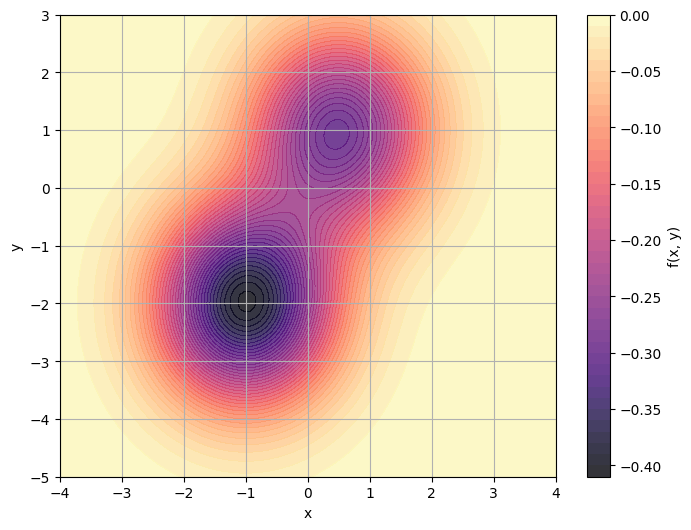

In [ ]:
X, Y = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-5, 3, 100))
Z = gauss_mixture(X, Y)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=40, cmap='magma', alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.colorbar(label="f(x, y)")

In [ ]:
# Your code

In [ ]:
LEARNING_RATE = 2
N_ITER = 40
current_point = np.array([-4,-3])

history = [current_point]
grad_norm = []

for _ in range(N_ITER):
  grad = gradient(x = current_point[0], y = current_point[1], func = gauss_mixture)
  current_point = current_point - LEARNING_RATE*gradient(x=current_point[0], y=current_point[1], func=gauss_mixture)
  history.append(current_point)
  grad_norm.append(np.linalg.norm(grad))

print(*history, sep='\n')
history = np.array(history)

[-4 -3]
[-3.98115919 -2.99563855]
[-3.96129153 -2.9910305 ]
[-3.94028953 -2.98614936]
[-3.91802879 -2.98096438]
[-3.89436437 -2.97543959]
[-3.86912619 -2.96953266]
[-3.84211313 -2.9631933 ]
[-3.81308527 -2.95636132]
[-3.78175376 -2.94896388]
[-3.74776711 -2.94091191]
[-3.71069273 -2.93209517]
[-3.6699913  -2.92237538]
[-3.62498072 -2.9115764 ]
[-3.5747844  -2.89947006]
[-3.51825521 -2.88575503]
[-3.45386132 -2.87002454]
[-3.37951    -2.85171568]
[-3.29226896 -2.8300272 ]
[-3.18791484 -2.80378189]
[-3.06019047 -2.77118936]
[-2.89959595 -2.72942985]
[-2.69160016 -2.67394054]
[-2.41509854 -2.59738441]
[-2.04734739 -2.48941712]
[-1.60096176 -2.34401666]
[-1.21292316 -2.18773809]
[-1.04147149 -2.07802661]
[-0.99788738 -2.02023931]
[-0.98724998 -1.99173558]
[-0.98425091 -1.97788937]
[-0.98323104 -1.97119902]
[-0.98282413 -1.96797244]
[-0.98264476 -1.96641733]
[-0.9825616  -1.96566795]
[-0.98252216 -1.96530685]
[-0.98250328 -1.96513285]
[-0.9824942  -1.96504901]
[-0.98248983 -1.96500861]
[-0.

In [ ]:
Z_history = A * np.exp(-((history[:, 0]**2) / (2 * sigma_x**2) +
                         (history[:, 1]**2) / (2 * sigma_y**2)))

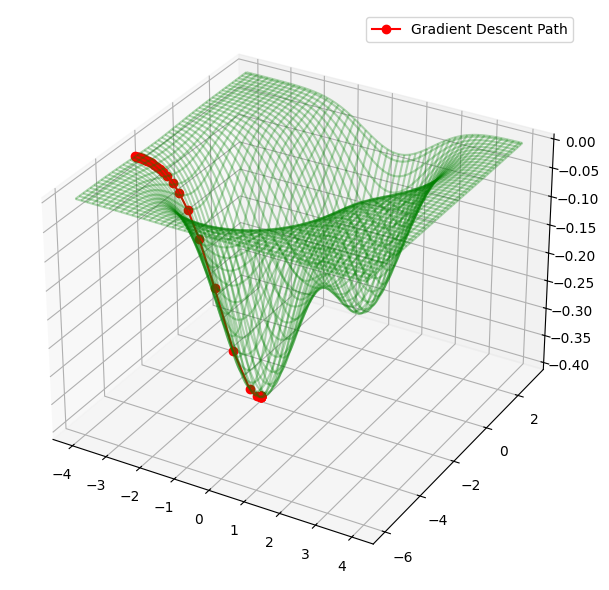

In [ ]:
#@title history plot
A_1 = -0.3
sigma_x_1 = 1.0
sigma_y_1 = 1.2
A_2 = -0.4
sigma_x_2 = 1
sigma_y_2 = 1.2
z = A_1 * np.exp(-(((x-.5)**2)/(2 * sigma_x_1**2) + ((y-1)**2)/(2 * sigma_y_1**2))) + \
A_2 * np.exp(-(((x + 1)**2)/(2 * sigma_x_2**2) + ((y + 2)**2)/(2 * sigma_y_2**2)))
for i in range(len(current_point)):
  def f(x, y):
      return (A_1 * np.exp(-(((x - 0.5)**2)/(2 * sigma_x_1**2) + ((y - 1)**2)/(2 * sigma_y_1**2))) +
              A_2 * np.exp(-(((x + 1)**2)/(2 * sigma_x_2**2) + ((y + 2)**2)/(2 * sigma_y_2**2))))

  Z_history = np.array([f(x_val, y_val) for x_val, y_val in history])



fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(X, Y, Z, color='green', alpha=0.3)

ax.plot(history[:, 0], history[:, 1], Z_history, color='red', marker='o', label='Gradient Descent Path')
ax.legend()

plt.tight_layout()
plt.show()
